In [10]:
import pandas as pd

In [11]:
df = pd.read_csv("sig_with_st.csv")

In [12]:
df.columns

Index(['PHQ_class', 'age_class', 'A2_gender', 'D1_daily_screen', 'A3_religion',
       'B1_residence', 'income_class', 'B4_family_type',
       'B5_time_with_parents_hours', 'B6_relationship_with_family',
       'weight_class', 'C3_physical_problems', 'D2_weekend_screen',
       'D3_device', 'D4_content', 'D5_parents_screen_time', 'D6_ai_daily',
       'D7_ai_impact', 'D8_creativity_decline', 'E1_sleep_duration',
       'E3_sleep_medicine', 'E5_bedtime', 'E6_wake_time',
       'F1_academic_satisfaction', 'F2_screen_impact', 'F3_learning_interest',
       'F4_interest_reduced', 'G1_mood_swings', 'G2_anxious_without_device',
       'G3_communication', 'G4_isolation', 'G5_negative_mental',
       'G6_panic_attack', 'H1_mobile_while_eating', 'H2_appetite_change',
       'BMI_class', 'D4_content_grouped'],
      dtype='object')

In [13]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Multinomial Logistic Regression — Screen Time (D1_daily_screen)

Significant predictors (p < 0.001) from chi-square analysis

In [14]:
# Significant predictors for Screen Time (p < 0.001)
sig_st = [
    'age_class', 'A2_gender', 'B1_residence', 'income_class',
    'weight_class', 'D2_weekend_screen', 'D4_content_grouped',
    'D5_parents_screen_time', 'D6_ai_daily', 'E5_bedtime',
    'E6_wake_time', 'F1_academic_satisfaction', 'F3_learning_interest',
    'F4_interest_reduced', 'G1_mood_swings', 'G2_anxious_without_device',
    'H1_mobile_while_eating', 'H2_appetite_change', 'BMI_class'
]

target_st = 'D1_daily_screen'

df_st = df[sig_st + [target_st]].dropna()

# Encode all categorical columns
le_dict_st = {}
df_enc_st = df_st.copy()
for col in df_enc_st.columns:
    le = LabelEncoder()
    df_enc_st[col] = le.fit_transform(df_enc_st[col].astype(str))
    le_dict_st[col] = le

X_st = df_enc_st[sig_st]
y_st = df_enc_st[target_st]

X_train_st, X_test_st, y_train_st, y_test_st = train_test_split(
    X_st, y_st, test_size=0.2, random_state=42, stratify=y_st
)

model_st = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
model_st.fit(X_train_st, y_train_st)

y_pred_st = model_st.predict(X_test_st)

print("=== Screen Time Model ===")
print(f"Classes: {le_dict_st[target_st].classes_}")
print(f"\nAccuracy: {accuracy_score(y_test_st, y_pred_st):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_st, y_pred_st,
                            target_names=le_dict_st[target_st].classes_))

=== Screen Time Model ===
Classes: ['1-3 hours' '3-5 hours' 'Less than 1 hour' 'More than 5 hours']

Accuracy: 0.5165

Classification Report:
                   precision    recall  f1-score   support

        1-3 hours       0.51      0.64      0.57        28
        3-5 hours       0.48      0.56      0.52        25
 Less than 1 hour       0.59      0.45      0.51        22
More than 5 hours       0.50      0.31      0.38        16

         accuracy                           0.52        91
        macro avg       0.52      0.49      0.50        91
     weighted avg       0.52      0.52      0.51        91



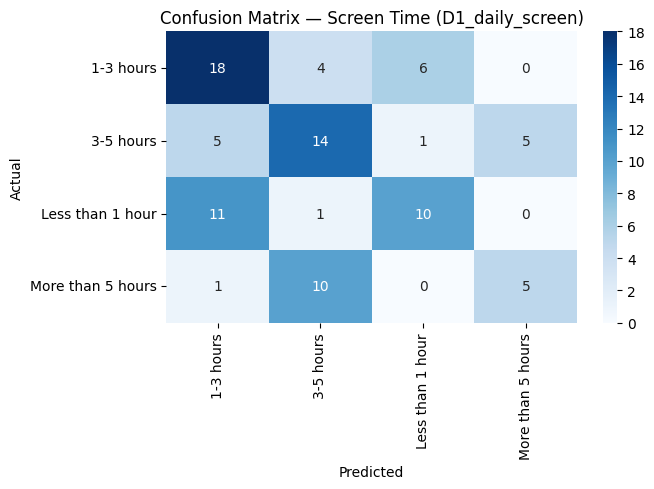

In [15]:
# Confusion matrix for Screen Time model
import seaborn as sns
import matplotlib.pyplot as plt

cm_st = confusion_matrix(y_test_st, y_pred_st)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_st, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_dict_st[target_st].classes_,
            yticklabels=le_dict_st[target_st].classes_)
plt.title('Confusion Matrix — Screen Time (D1_daily_screen)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [16]:
# Coefficient table: odds ratios per class for Screen Time model
classes_st = le_dict_st[target_st].classes_
coef_df_st = pd.DataFrame(
    np.exp(model_st.coef_),
    index=classes_st,
    columns=sig_st
).T

coef_df_st.columns = [f'OR ({c})' for c in classes_st]
coef_df_st.index.name = 'Predictor'
print("Odds Ratios — Screen Time Model (exp(coef)):")
coef_df_st.round(3)

Odds Ratios — Screen Time Model (exp(coef)):


,OR (1-3 hours),OR (3-5 hours),OR (Less than 1 hour),OR (More than 5 hours)
Predictor,,,,
age_class,0.584,1.264,0.652,2.077
A2_gender,0.877,1.953,0.506,1.154
B1_residence,0.548,1.212,0.903,1.669
income_class,0.758,0.883,1.809,0.827
weight_class,1.123,0.686,1.240,1.048
D2_weekend_screen,1.486,0.161,21.611,0.193
D4_content_grouped,0.976,1.458,0.680,1.033
D5_parents_screen_time,1.154,0.945,1.997,0.459
D6_ai_daily,0.847,1.204,1.020,0.961
